# Final Project Draft: Tottenham Hotspur Recruitment Fit Model

This notebook builds a draft machine learning workflow for identifying football players who fit Tottenham Hotspur's recruitment profile. It uses four seasons of Premier League player data and compares K-Means clustering with Random Forest regression.

## 1. Imports and Setup

In [5]:
import os
import time
from pathlib import Path

os.environ['OMP_NUM_THREADS'] = '1'

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42

## 2. Load the Dataset

In [23]:
season_paths = ['2021-22', '2022-23', '2023-24', '2024-25']
position_map = {1: 'GK', 2: 'DEF', 3: 'MID', 4: 'FWD'}
frames = []

for season in season_paths:
    players = pd.read_csv(Path('data/fpl_raw') / season / 'players_raw.csv')
    teams = pd.read_csv(Path('data/fpl_raw') / season / 'teams.csv')[['id', 'name', 'short_name', 'strength', 'strength_attack_home', 'strength_defence_home']].rename(columns={'id': 'team', 'name': 'team_name'})
    season_df = players.merge(teams, on='team', how='left')
    season_df['season'] = season
    season_df['position'] = season_df['element_type'].map(position_map)
    frames.append(season_df)

raw_df = pd.concat(frames, ignore_index=True)
for col in ['creativity', 'influence', 'threat', 'ict_index', 'points_per_game', 'selected_by_percent', 'form']:
    raw_df[col] = pd.to_numeric(raw_df[col], errors='coerce')

raw_df['player_name'] = raw_df['first_name'] + ' ' + raw_df['second_name']
raw_df['is_spurs'] = (raw_df['short_name'] == 'TOT').astype(int)

df = raw_df[raw_df['position'].isin(['DEF', 'MID', 'FWD'])].copy()
df = df[df['minutes'] >= 270].copy()
df = df.sort_values(by='is_spurs', ascending=False)

print('Observations after filtering:', df.shape[0])
print('Columns:', df.shape[1])
display(df[['player_name', 'season', 'team_name', 'position', 'minutes', 'goals_scored', 'assists', 'now_cost']].head())

Observations after filtering: 1625
Columns: 112


,player_name,season,team_name,position,minutes,goals_scored,assists,now_cost
582,Harry Kane,2021-22,Spurs,FWD,3231,17,11,125
3060,Rodrigo Bentancur,2024-25,Spurs,MID,1640,2,0,49
3062,Yves Bissouma,2024-25,Spurs,MID,1396,2,0,48
3064,Ben Davies,2024-25,Spurs,DEF,1329,0,0,43
3066,Radu Drăgușin,2024-25,Spurs,DEF,1250,0,0,43


## 3. Exploratory Analysis

In [7]:
print('Dataset shape:', df.shape)
print('Seasons included:', sorted(df['season'].unique().tolist()))
print('Position counts:')
print(df['position'].value_counts())
print()
print('Tottenham observations:', int(df['is_spurs'].sum()))
print('Non-Tottenham observations:', int((1 - df['is_spurs']).sum()))

missing_summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_values': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2)
}).sort_values(['missing_values', 'dtype'], ascending=[False, True])

display(missing_summary.head(20))

Dataset shape: (1625, 112)
Seasons included: ['2021-22', '2022-23', '2023-24', '2024-25']
Position counts:
position
MID    772
DEF    652
FWD    201
Name: count, dtype: int64

Tottenham observations: 79
Non-Tottenham observations: 1546


,dtype,missing_values,missing_pct
corners_and_indirect_freekicks_text,float64,1625,100.00
direct_freekicks_text,float64,1625,100.00
penalties_text,float64,1625,100.00
squad_number,float64,1625,100.00
penalties_order,float64,1398,86.03
direct_freekicks_order,float64,1349,83.02
corners_and_indirect_freekicks_order,float64,1316,80.98
news,object,1280,78.77
birth_date,object,1233,75.88
mng_clean_sheets,float64,1223,75.26


In [8]:
eda_numeric = ['minutes', 'goals_scored', 'assists', 'creativity', 'influence', 'threat', 'ict_index', 'now_cost', 'points_per_game', 'form']
display(df[eda_numeric].describe().T[['mean', 'std', 'min', 'max']])

,mean,std,min,max
minutes,1654.156923,872.248493,270.0,3420.0
goals_scored,2.651692,3.896352,0.0,36.0
assists,2.361846,2.835736,0.0,18.0
creativity,274.429354,258.967911,0.2,1818.5
influence,364.352123,237.107612,13.0,1577.0
threat,276.587077,291.546659,0.0,2091.0
ict_index,91.484923,68.104932,3.7,476.0
now_cost,52.252308,13.057955,37.0,149.0
points_per_game,2.645969,1.133958,0.1,9.1
form,1.822769,1.783445,-0.4,9.5


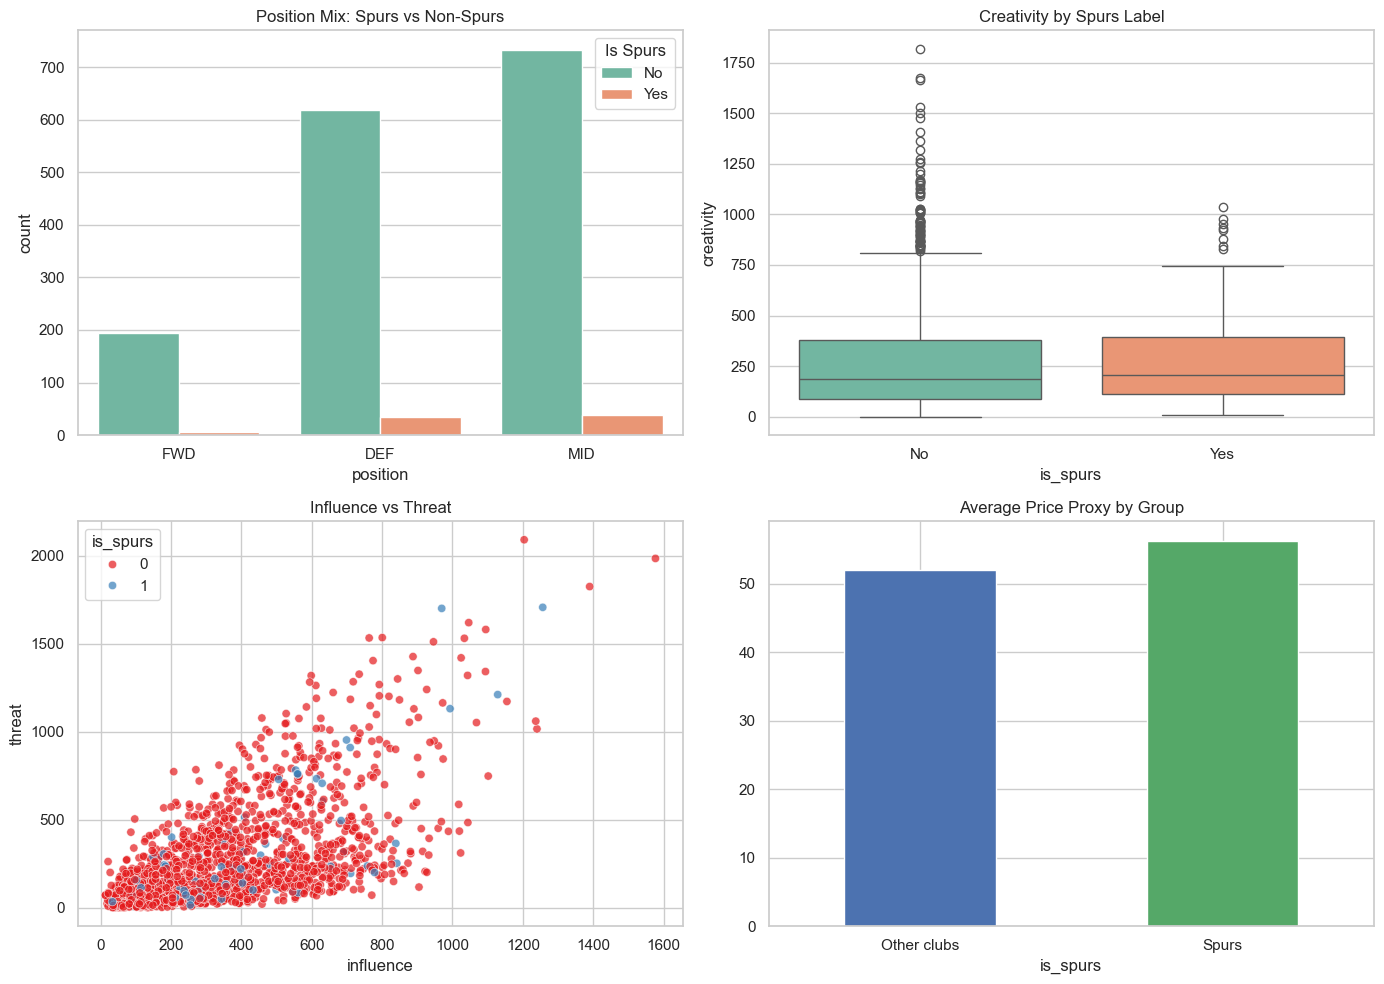

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x='position', hue='is_spurs', palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('Position Mix: Spurs vs Non-Spurs')
axes[0, 0].legend(title='Is Spurs', labels=['No', 'Yes'])

sns.boxplot(data=df, x='is_spurs', y='creativity', hue='is_spurs', palette='Set2', dodge=False, legend=False, ax=axes[0, 1])
axes[0, 1].set_title('Creativity by Spurs Label')
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_xticklabels(['No', 'Yes'])

sns.scatterplot(data=df, x='influence', y='threat', hue='is_spurs', palette='Set1', alpha=0.7, ax=axes[1, 0])
axes[1, 0].set_title('Influence vs Threat')

team_cost = df.groupby('is_spurs')['now_cost'].mean().rename({0: 'Other clubs', 1: 'Spurs'})
team_cost.plot(kind='bar', color=['#4C72B0', '#55A868'], ax=axes[1, 1])
axes[1, 1].set_title('Average Price Proxy by Group')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Key data characteristics:**

The filtered draft dataset contains more than 1,600 outfield player-season observations across four Premier League seasons. Tottenham players are a small minority of the data, so a continuous fit-score approach makes more sense than a simple classification label. The feature distributions also vary a lot by position, which means position-aware similarity modeling is important.

## 4. Engineer Custom Features

In [10]:
df['goal_involvement_per90'] = ((df['goals_scored'] + df['assists']) / df['minutes'].clip(lower=1)) * 90
df['creativity_threat_balance'] = df['creativity'] / (df['threat'] + 1)
df['bps_per90'] = (df['bps'] / df['minutes'].clip(lower=1)) * 90
df['availability_value_index'] = df['minutes'] / df['now_cost'].clip(lower=1)

engineered_cols = ['goal_involvement_per90', 'creativity_threat_balance', 'bps_per90', 'availability_value_index']
display(df[['player_name', 'season', 'position'] + engineered_cols].head())

,player_name,season,position,goal_involvement_per90,creativity_threat_balance,bps_per90,availability_value_index
3,Pierre-Emerick Aubameyang,2021-22,FWD,0.434363,0.227101,11.380309,10.791667
4,Cédric Soares,2021-22,DEF,0.121540,3.980519,17.744767,35.261905
5,Alexandre Lacazette,2021-22,FWD,0.609137,0.532000,14.974619,21.888889
6,Granit Xhaka,2021-22,MID,0.116029,1.927559,12.917920,48.479167
10,Mohamed Naser El Sayed Elneny,2021-22,MID,0.224719,3.036585,17.528090,18.204545


**Feature justifications:**

1. `goal_involvement_per90` measures attacking production relative to playing time.
2. `creativity_threat_balance` helps distinguish creators from direct scorers.
3. `bps_per90` captures broader contribution at a rate level.
4. `availability_value_index` acts as a draft affordability and reliability proxy.

## 5. Build the Tottenham Fit Score

In [11]:
style_cols = ['creativity', 'influence', 'threat', 'ict_index', 'goal_involvement_per90', 'bps_per90', 'clean_sheets']
for col in style_cols:
    group_stats = df.groupby('position')[col]
    std = group_stats.transform('std').replace(0, np.nan)
    df[f'{col}_z'] = (df[col] - group_stats.transform('mean')) / std

z_cols = [f'{col}_z' for col in style_cols]
spurs_centroids = df[df['is_spurs'] == 1].groupby('position')[z_cols].mean()

def cosine_similarity(vec_a, vec_b):
    vec_a = np.asarray(vec_a, dtype=float)
    vec_b = np.asarray(vec_b, dtype=float)
    if np.isnan(vec_a).any() or np.isnan(vec_b).any():
        return np.nan
    denom = np.linalg.norm(vec_a) * np.linalg.norm(vec_b)
    if denom == 0:
        return 0.0
    return float(np.dot(vec_a, vec_b) / denom)

style_similarity_raw = []
for _, row in df.iterrows():
    centroid = spurs_centroids.loc[row['position']]
    style_similarity_raw.append(cosine_similarity(row[z_cols], centroid))

df['style_similarity_raw'] = style_similarity_raw

def minmax_0_100(series):
    series = series.astype(float)
    min_val, max_val = series.min(), series.max()
    if max_val - min_val == 0:
        return pd.Series(50.0, index=series.index)
    return (series - min_val) / (max_val - min_val) * 100

df['style_similarity_score'] = minmax_0_100(df['style_similarity_raw'])
df['affordability_score'] = minmax_0_100(-df['now_cost'])
df['availability_score'] = minmax_0_100(df['minutes'])
df['tottenham_fit_score'] = 0.65 * df['style_similarity_score'] + 0.20 * df['affordability_score'] + 0.15 * df['availability_score']

print(df['tottenham_fit_score'].agg(['min', 'max', 'mean', 'std']).round(2))
display(df[['player_name', 'season', 'team_name', 'position', 'tottenham_fit_score']].sort_values('tottenham_fit_score', ascending=False).head(10))

min      9.95
max     91.48
mean    52.96
std     21.20
Name: tottenham_fit_score, dtype: float64


,player_name,season,team_name,position,tottenham_fit_score
1108,Timothy Castagne,2022-23,Leicester,DEF,91.479204
3171,Jørgen Strand Larsen,2024-25,Wolves,FWD,90.815701
1846,Jean-Philippe Mateta,2023-24,Crystal Palace,FWD,90.329945
2362,Matheus Santos Carneiro Da Cunha,2023-24,Wolves,FWD,90.327761
2526,Yoane Wissa,2024-25,Brentford,FWD,90.302053
2060,Joško Gvardiol,2023-24,Man City,DEF,90.185368
2273,Pedro Porro,2023-24,Spurs,DEF,89.824912
2035,Nathan Aké,2023-24,Man City,DEF,89.774206
594,Sergio Reguilón,2021-22,Spurs,DEF,89.461468
60,Matthew Cash,2021-22,Aston Villa,DEF,89.363137


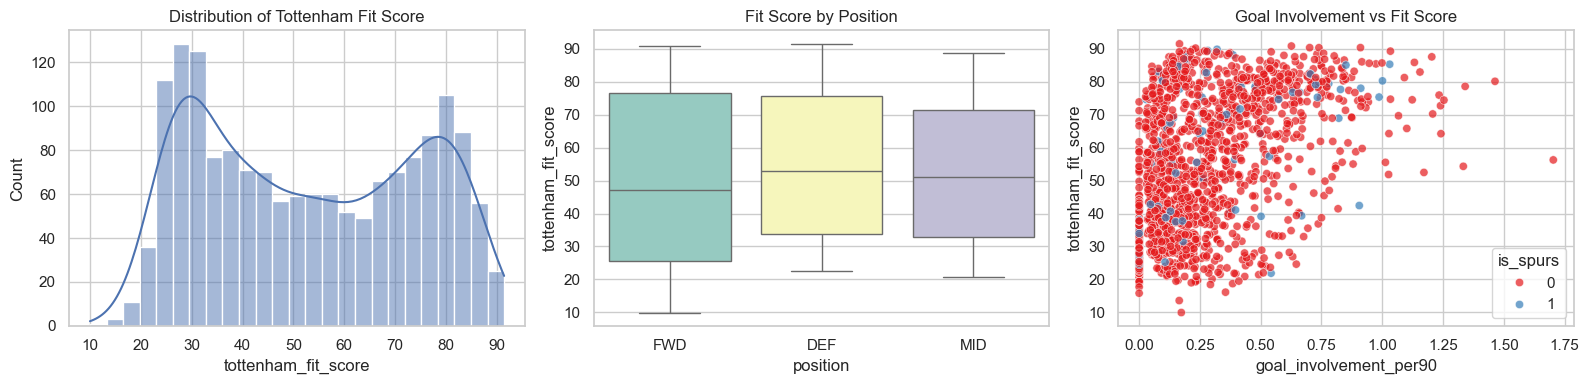

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df['tottenham_fit_score'], bins=25, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribution of Tottenham Fit Score')

sns.boxplot(data=df, x='position', y='tottenham_fit_score', hue='position', palette='Set3', dodge=False, legend=False, ax=axes[1])
axes[1].set_title('Fit Score by Position')

sns.scatterplot(data=df, x='goal_involvement_per90', y='tottenham_fit_score', hue='is_spurs', palette='Set1', alpha=0.7, ax=axes[2])
axes[2].set_title('Goal Involvement vs Fit Score')

plt.tight_layout()
plt.show()

## 6. Prepare Data for Modeling

In [13]:
model_features = ['goals_scored', 'assists', 'clean_sheets', 'creativity', 'influence', 'threat', 'ict_index', 'bonus', 'bps', 'minutes', 'now_cost', 'points_per_game', 'selected_by_percent', 'form', 'goal_involvement_per90', 'creativity_threat_balance', 'bps_per90', 'availability_value_index', 'strength', 'strength_attack_home', 'strength_defence_home', 'position', 'season']

X = df[model_features].copy()
y = df['tottenham_fit_score'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=df['position'])

numeric_features = [col for col in model_features if col not in ['position', 'season']]
categorical_features = ['position', 'season']

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print(X_train['position'].value_counts())

Train shape: (1300, 23)
Test shape: (325, 23)
position
MID    618
DEF    521
FWD    161
Name: count, dtype: int64


## 7. Model 1: K-Means Clustering

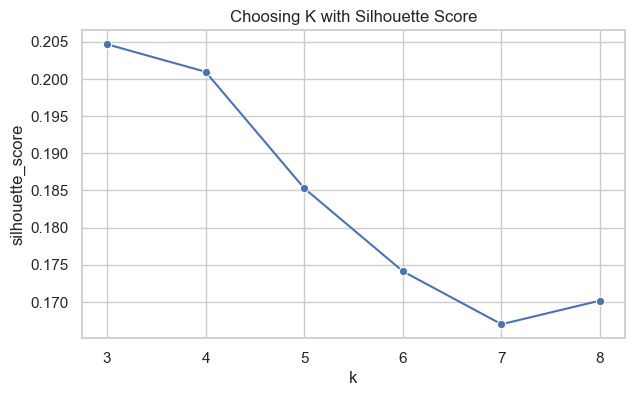

Best k selected for K-Means: 3


,k,silhouette_score
0,3,0.204661
1,4,0.200956
2,5,0.185291
3,6,0.174120
4,7,0.166999
5,8,0.170183


In [14]:
silhouette_results = []
for k in range(3, 9):
    candidate_model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    cluster_labels = candidate_model.fit_predict(X_train_processed)
    silhouette_results.append({'k': k, 'silhouette_score': silhouette_score(X_train_processed, cluster_labels)})

silhouette_df = pd.DataFrame(silhouette_results)
best_k = int(silhouette_df.sort_values('silhouette_score', ascending=False).iloc[0]['k'])

plt.figure(figsize=(7, 4))
sns.lineplot(data=silhouette_df, x='k', y='silhouette_score', marker='o')
plt.title('Choosing K with Silhouette Score')
plt.show()

print('Best k selected for K-Means:', best_k)
display(silhouette_df)

In [15]:
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
train_clusters = kmeans.fit_predict(X_train_processed)
test_clusters = kmeans.predict(X_test_processed)

cluster_fit_lookup = pd.DataFrame({'cluster': train_clusters, 'fit_score': y_train.reset_index(drop=True)}).groupby('cluster')['fit_score'].mean()
kmeans_predictions = pd.Series(test_clusters).map(cluster_fit_lookup).to_numpy()

kmeans_rmse = mean_squared_error(y_test, kmeans_predictions) ** 0.5
kmeans_mae = mean_absolute_error(y_test, kmeans_predictions)
kmeans_r2 = r2_score(y_test, kmeans_predictions)

print('K-Means baseline metrics')
print('RMSE:', round(kmeans_rmse, 4))
print('MAE:', round(kmeans_mae, 4))
print('R^2:', round(kmeans_r2, 4))

K-Means baseline metrics
RMSE: 14.796
MAE: 11.9429
R^2: 0.5224


,players,avg_fit_score,spurs_share
cluster,,,
0,174,79.071961,5.75
2,469,64.690093,5.12
1,657,37.803028,4.87


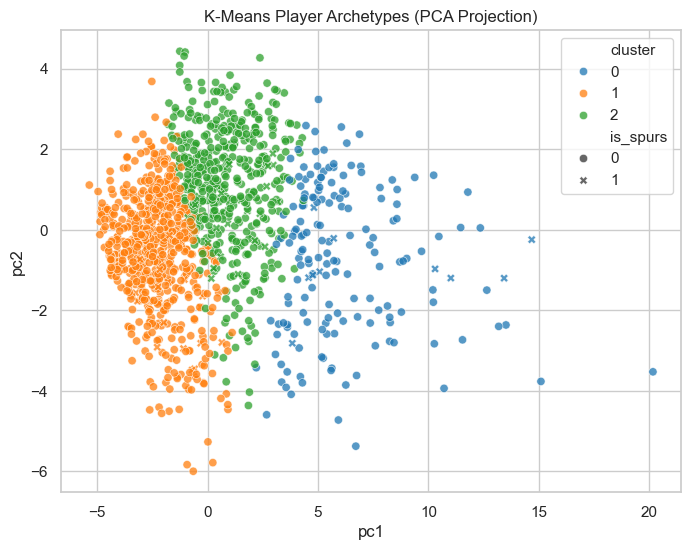

In [16]:
train_cluster_df = X_train.copy()
train_cluster_df['cluster'] = train_clusters
train_cluster_df['fit_score'] = y_train.values
train_cluster_df['is_spurs'] = df.loc[X_train.index, 'is_spurs'].values

cluster_summary = train_cluster_df.groupby('cluster').agg(players=('cluster', 'size'), avg_fit_score=('fit_score', 'mean'), spurs_share=('is_spurs', 'mean')).sort_values('avg_fit_score', ascending=False)
cluster_summary['spurs_share'] = (cluster_summary['spurs_share'] * 100).round(2)
display(cluster_summary)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
train_pca = pca.fit_transform(X_train_processed)
plot_df = pd.DataFrame({'pc1': train_pca[:, 0], 'pc2': train_pca[:, 1], 'cluster': train_clusters, 'is_spurs': train_cluster_df['is_spurs'].values})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x='pc1', y='pc2', hue='cluster', style='is_spurs', alpha=0.75, palette='tab10')
plt.title('K-Means Player Archetypes (PCA Projection)')
plt.show()

## 8. Model 2: Random Forest Regression

In [17]:
rf = RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_leaf=4, random_state=RANDOM_STATE)

start_time = time.time()
rf.fit(X_train_processed, y_train)
rf_train_time = time.time() - start_time

rf_predictions = rf.predict(X_test_processed)
rf_rmse = mean_squared_error(y_test, rf_predictions) ** 0.5
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print('Random Forest metrics')
print('RMSE:', round(rf_rmse, 4))
print('MAE:', round(rf_mae, 4))
print('R^2:', round(rf_r2, 4))
print('Training time (s):', round(rf_train_time, 4))

Random Forest metrics
RMSE: 4.9568
MAE: 3.5753
R^2: 0.9464
Training time (s): 3.31


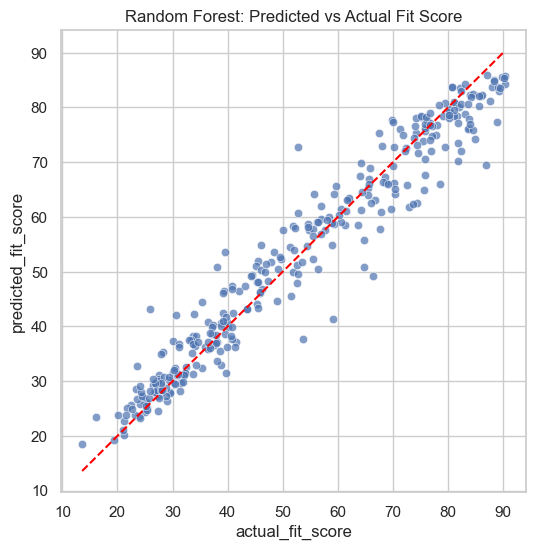

In [18]:
comparison_plot = pd.DataFrame({'actual_fit_score': y_test.values, 'predicted_fit_score': rf_predictions})

plt.figure(figsize=(6, 6))
sns.scatterplot(data=comparison_plot, x='actual_fit_score', y='predicted_fit_score', alpha=0.7)
plt.plot([comparison_plot.min().min(), comparison_plot.max().max()], [comparison_plot.min().min(), comparison_plot.max().max()], color='red', linestyle='--')
plt.title('Random Forest: Predicted vs Actual Fit Score')
plt.show()

## 9. Compare Model Performance

In [19]:
results = pd.DataFrame([
    {'Model': 'K-Means cluster baseline', 'Key hyperparameters': f'k={best_k}, n_init=20', 'RMSE': kmeans_rmse, 'MAE': kmeans_mae, 'R2': kmeans_r2, 'Training time (s)': np.nan, 'Interpretability': 'High for archetypes', 'Overfitting signs': 'Low, but limited predictive precision'},
    {'Model': 'Random Forest Regressor', 'Key hyperparameters': 'n_estimators=300, max_depth=10, min_samples_leaf=4', 'RMSE': rf_rmse, 'MAE': rf_mae, 'R2': rf_r2, 'Training time (s)': rf_train_time, 'Interpretability': 'Moderate via feature importance', 'Overfitting signs': 'Monitor with learning curve'}
])

results_display = results.copy()
for col in ['RMSE', 'MAE', 'R2', 'Training time (s)']:
    results_display[col] = results_display[col].round(4)
display(results_display)

,Model,Key hyperparameters,RMSE,MAE,R2,Training time (s),Interpretability,Overfitting signs
0,K-Means cluster baseline,"k=3, n_init=20",14.7960,11.9429,0.5224,NaN,High for archetypes,"Low, but limited predictive precision"
1,Random Forest Regressor,"n_estimators=300, max_depth=10, min_samples_le...",4.9568,3.5753,0.9464,3.31,Moderate via feature importance,Monitor with learning curve


**Model comparison analysis:**

Random Forest performs much better than the K-Means baseline on the held-out test set. K-Means is still useful because it gives interpretable player archetypes, but it is not as strong for precise score prediction. For the final version, I would keep K-Means as the tactical profiling tool and use Random Forest as the main predictive model.

## 10. Training and Validation Visualization

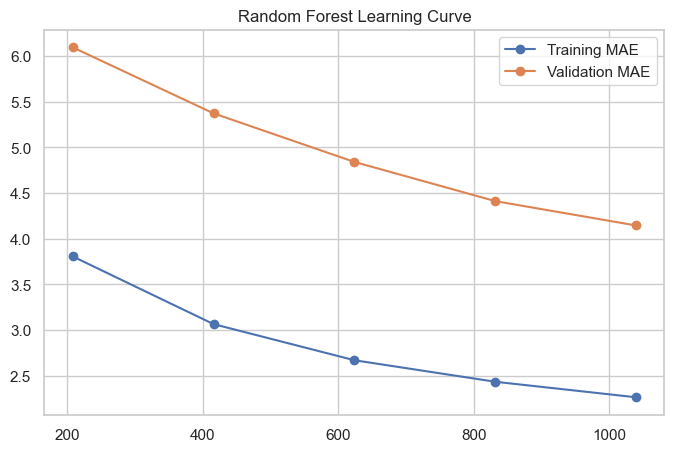

In [20]:
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_leaf=4, random_state=RANDOM_STATE),
    X=X_train_processed,
    y=y_train,
    cv=5,
    scoring='neg_mean_absolute_error',
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=1
)

train_mae = -train_scores.mean(axis=1)
validation_mae = -validation_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mae, marker='o', label='Training MAE')
plt.plot(train_sizes, validation_mae, marker='o', label='Validation MAE')
plt.title('Random Forest Learning Curve')
plt.legend()
plt.show()

,feature,importance
4,num__influence,0.412916
8,num__bps,0.155250
16,num__bps_per90,0.145324
11,num__points_per_game,0.084190
14,num__goal_involvement_per90,0.044469
6,num__ict_index,0.042620
22,cat__position_FWD,0.015882
12,num__selected_by_percent,0.015610
21,cat__position_DEF,0.015152
5,num__threat,0.013854


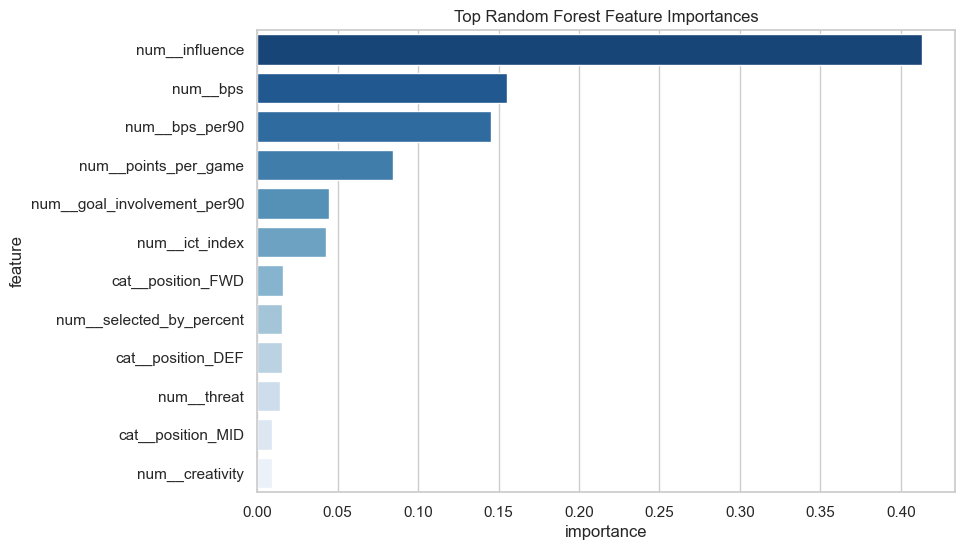

In [21]:
feature_names = preprocessor.get_feature_names_out()
feature_importance = pd.DataFrame({'feature': feature_names, 'importance': rf.feature_importances_}).sort_values('importance', ascending=False)
display(feature_importance.head(15))

plt.figure(figsize=(9, 6))
top_features = feature_importance.head(12).copy()
sns.barplot(data=top_features, x='importance', y='feature', hue='feature', palette='Blues_r', dodge=False, legend=False)
plt.title('Top Random Forest Feature Importances')
plt.show()

## 11. Example Recruitment Recommendations

In [22]:
all_processed = preprocessor.transform(X)
df['predicted_fit_score_rf'] = rf.predict(all_processed)

recommendations = (
    df[df['is_spurs'] == 0][['player_name', 'season', 'team_name', 'position', 'now_cost', 'goal_involvement_per90', 'predicted_fit_score_rf']]
    .sort_values('predicted_fit_score_rf', ascending=False)
    .head(15)
    .reset_index(drop=True)
)
recommendations['goal_involvement_per90'] = recommendations['goal_involvement_per90'].round(2)
recommendations['predicted_fit_score_rf'] = recommendations['predicted_fit_score_rf'].round(2)
display(recommendations)

,player_name,season,team_name,position,now_cost,goal_involvement_per90,predicted_fit_score_rf
0,Jean-Philippe Mateta,2023-24,Crystal Palace,FWD,51,0.91,86.94
1,Matthew Cash,2021-22,Aston Villa,DEF,53,0.19,86.89
2,Timothy Castagne,2022-23,Leicester,DEF,43,0.17,86.83
3,Pervis Estupiñán,2022-23,Brighton,DEF,50,0.27,86.80
4,Raúl Jiménez,2024-25,Fulham,FWD,53,0.54,86.62
5,Jørgen Strand Larsen,2024-25,Wolves,FWD,52,0.63,86.28
6,João Pedro Junqueira de Jesus,2024-25,Brighton,FWD,55,0.74,86.26
7,Marcos Alonso,2021-22,Chelsea,DEF,57,0.37,86.16
8,Marc Cucurella Saseta,2024-25,Chelsea,DEF,54,0.21,86.00
9,Matheus Santos Carneiro Da Cunha,2024-25,Wolves,FWD,70,0.76,85.98


## 12. Reflection and Next Steps

**Feature engineering plans:** In the final version, I want to replace the FPL price proxy with real Transfermarkt values and add richer tactical features from FBref.

**Model optimization plans:** Random Forest is the stronger draft model, so the next step is hyperparameter tuning with cross-validation.

**Questions for instructor feedback:** I would like feedback on whether the engineered fit score is an acceptable draft target and whether narrowing the draft to Premier League data is a reasonable prototype for a later multi-league final version.